<a href="https://colab.research.google.com/github/GoudoMahan/AI-agent-practice/blob/main/Homework01_Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab: AI Agent与具身智能 —— 拥抱AI辅助编程

欢迎来到本次Lab！作为未来的AI工程师和具身智能研究者，掌握如何高效地使用大语言模型（如 ChatGPT, Claude, Kimi 等）来辅助编写、调试代码，是提升科研效率的核心技能。

即使你没有编程基础也不用担心——本次 Lab 的核心目标不是手写代码，而是体验如何作为“项目经理”：给 AI 下达指令、测试 AI 写的代码、遇到报错时把错误信息反馈给 AI 让它自我修复。

## 📝 任务提交流程与要求
对于接下来的每一个子任务，你需要：
1. **编写 Prompt：** 根据任务描述，在文本单元格中记录你给 AI 下达的指令。
2. **运行与测试：** 将 AI 生成的代码粘贴到 Code Cell 中运行。
3. **Debug 环节（如果报错）：** 编程中报错是家常便饭。如果代码运行失败，请不要慌张。直接复制**你的代码**和**终端里红色的报错信息**，发给 AI，让它帮你修改。然后在 Debug 专属的单元格中记录这个过程。

> **📌 提示：** 在给 AI 的 prompt 中，请强调**所有图表（标题、坐标轴、图例等）必须使用英文**，防止中文乱码。


# Task 1: 图像分类 (Fashion MNIST)

**【任务大背景】**
Fashion MNIST 是一个经典的计算机视觉入门数据集。它包含 10 个类别的服饰灰度图（28x28）。在这个任务中，你的目标是教 AI 学会“认衣服”。我们将分三步完成这个过程：首先是“数据准备”，把几万张衣服照片下载并打包好喂给模型；接着是“模型搭建”，给 AI 构建一个能提取图片特征的“数字大脑”；最后是“训练评估”，让 AI 通过不断“做题”和“对答案”来纠正错误、提高准确率，并最终测试它的学习成绩。

---

## Part 1.0: 环境准备与依赖安装（必做）

**【目的】**
先一次性安装 Task 1（Fashion MNIST）可能用到的依赖，后续 Part 1.1~1.6 直接复用环境。

**【说明】**
- 这个环节不需要 AI 生成代码。
- 直接运行下方代码 cell 即可。
- 建议在 Colab T4 GPU 环境下执行。

In [ ]:
# Task 1 依赖安装（不需要 AI 生成）

# 深度学习与数据集
!pip -q install torch torchvision torchaudio

# 可视化与常用工具
!pip -q install matplotlib numpy

print("Task 1 依赖安装完成。")

Task 1 依赖安装完成。


## Part 1.1: 数据准备与 DataLoader 构建


### Part 1.1 学习导航：先让模型“看到数据”

**这一部分在做什么？**
你将下载 Fashion MNIST 训练集与测试集，并做最基础的数据可视化检查。

**为什么第一步一定是数据？**
机器学习里有一句话："Garbage in, garbage out"。输入数据有问题，后面模型再复杂也学不好。

**输入 / 输出**
- 输入：`torchvision.datasets.FashionMNIST` 官方数据源
- 输出：`train_dataset`、`test_dataset`、`transform`

**你应该看到什么结果？**
- 训练集/测试集样本数打印正常
- 至少 5 张样本图可视化成功，标签与图像看起来匹配

![Part 1.1 数据准备图](https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/doc/img/fashion-mnist-sprite.png)

**图片讲解（你应该怎么读这张图）**
- 这是一张把 10 个类别样本拼在一起的总览图，每个小图对应一个服饰类别。
- 先观察“相似类别”的差异：比如 `Shirt` 和 `T-shirt/top` 轮廓接近，说明模型很容易混淆。
- 再观察“清晰类别”的特征：例如 `Trouser` 形状单一，通常更容易被分类正确。
- 这张图的意义是：在训练前先建立直觉，知道数据到底难在哪里。

> 看图要点：不同类别外观可能很像（例如 Shirt / T-shirt），这也是后面模型训练的挑战来源。

**📖 概念解释**
- **训练集 / 测试集**：训练集用来训练模型；测试集用来评估模型在“从未见过的数据”上的表现，避免“背答案”式的虚假高分。
- **Dataset（数据集）**：像“仓库”，存放所有样本（如图片和对应标签）。Fashion MNIST 训练集有 60000 张图。
- **batch / batch_size（批次 / 批次大小）**：训练时不会一次喂入全部数据，而是每次取一小批。这一小批就叫一个 **batch**，`batch_size=64` 表示每次取 64 张图。这样做的原因：节省内存、加速训练、引入随机性。
- **DataLoader**：像“配送车”，按 batch 从 Dataset 里取数据，一次 `next(iter(train_loader))` 就得到一个 batch 的图片和标签。
- **transform（数据变换）**：对原始图片做预处理，如转成张量、归一化，让模型更易学习。
- **shuffle**：`shuffle=True` 表示每轮取数据前先打乱顺序，避免模型只记住固定顺序而学不好。

**DataLoader 关键理解**
- 数据流转：`Dataset -> DataLoader -> Model -> Loss -> Optimizer`。
- 后续最关键检查：`images.shape` 与 `labels.shape` 是否符合预期（如 `[64, 1, 28, 28]` 表示 64 张 28×28 的单通道图）。

**【你要做什么】**
让 AI 写一段最小可运行代码：使用 `torchvision.datasets.FashionMNIST` 下载训练集和测试集（含必要 `transform`），并打印训练集/测试集样本数。

**【可视化验证（建议必须做）】**
在同一个代码 cell 中，额外可视化显示 5 张样本图（`matplotlib`），并在标题显示类别名，让你直观看到数据到底长什么样。

**【衔接要求】**
从下一部分开始，默认复用这一部分变量（如 `train_dataset`、`test_dataset`、`transform`），不要重复下载数据。

**【通过标准】**
1. 成功打印训练集和测试集样本数。
2. 成功显示若干样本图和标签。

**时间建议：** 约 2 分钟。

建议在同一个代码 cell 里一次完成“数据下载 + DataLoader 构建 + batch 检查可视化”，并额外展示 16 张 batch 网格图（4x4）。
提交前确认：`train_loader`、`test_loader` 已创建，且已打印 `images.shape`、`labels.shape`。

### 📋 可复制给 AI 的提示词（先复制，再按需微调）
我现在在做 Fashion MNIST 作业，当前进行到 Part 1.1（数据准备与 DataLoader 构建）。请帮我在**一个代码 cell**里一次性完成：
1) 下载训练集和测试集，创建 `train_dataset`、`test_dataset`、`transform`；
2) 创建 `train_loader` 和 `test_loader`（如 `batch_size=64`）；
3) 打印一个 batch 的 `images.shape` 与 `labels.shape`；
4) 可视化 5 张样本图和 16 张 batch 网格图。
**【重要】** 所有图表（标题、坐标轴、图例、标签等）必须使用英文，防止中文乱码。
要求：训练与推理统一使用 Colab T4 GPU（cuda）；请只输出可直接运行的纯 Python 代码，保留少量中文注释，不要输出解释文字。

**👨‍💻 请在下方 AI prompt cell 中填写 prompt，并将 AI 生成代码粘贴到后面的 Code cell 运行。**

In [ ]:
# @title AI prompt cell

import ipywidgets as widgets
from IPython.display import display, HTML, Markdown,clear_output
from google.colab import ai

dropdown = widgets.Dropdown(
    options=[],
    layout={'width': 'auto'}
)

def update_model_list(new_options):
    dropdown.options = new_options
update_model_list(ai.list_models())

text_input = widgets.Textarea(
    placeholder='Ask me anything....',
    layout={'width': 'auto', 'height': '100px'},
)

button = widgets.Button(
    description='Submit Text',
    disabled=False,
    tooltip='Click to submit the text',
    icon='check'
)

output_area = widgets.Output(
     layout={'width': 'auto', 'max_height': '300px','overflow_y': 'scroll'}
)

def on_button_clicked(b):
    with output_area:
        output_area.clear_output(wait=False)
        accumulated_content = ""
        for new_chunk in ai.generate_text(prompt=text_input.value, model_name=dropdown.value, stream=True):
            if new_chunk is None:
                continue
            accumulated_content += new_chunk
            clear_output(wait=True)
            display(Markdown(accumulated_content))

button.on_click(on_button_clicked)
vbox = widgets.GridBox([dropdown, text_input, button, output_area])

display(HTML("""
<style>
.widget-dropdown select {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
.widget-textarea textarea {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
</style>
"""))
display(vbox)


GridBox(children=(Dropdown(layout=Layout(width='auto'), options=('google/gemini-2.5-flash', 'google/gemini-2.5…

Using device: cuda
Number of training samples: 60000
Number of test samples: 10000
Number of training batches (batch_size=64): 938
Number of test batches (batch_size=64): 157

Shape of images in one batch: torch.Size([64, 1, 28, 28])
Shape of labels in one batch: torch.Size([64])

--- Visualizing 5 Random Training Samples ---


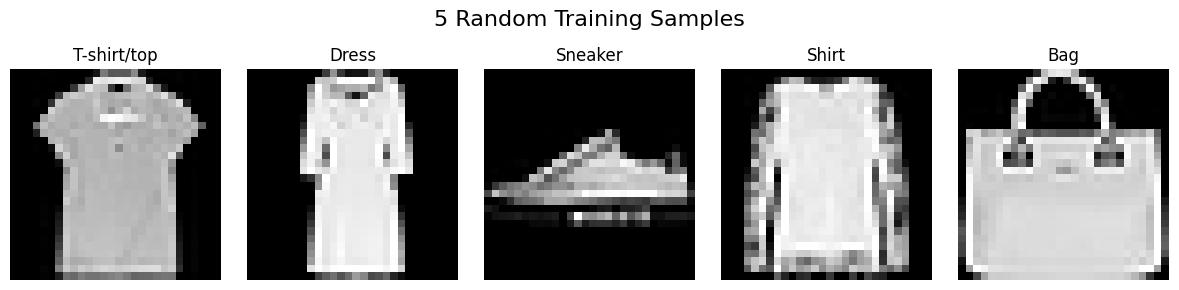


--- Visualizing a Batch Grid of 16 Images ---


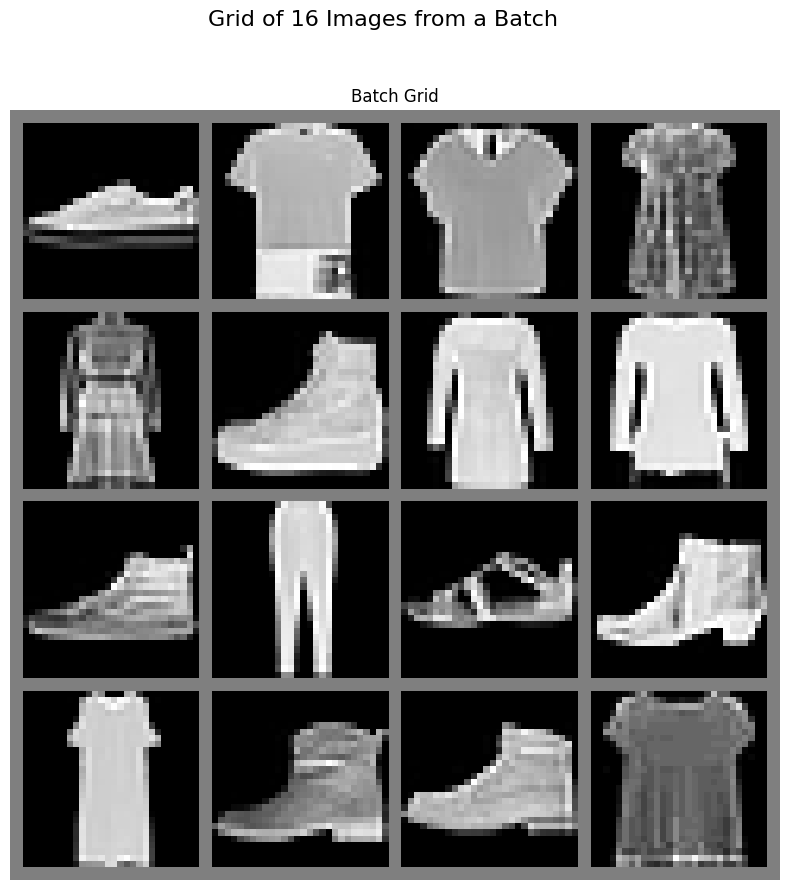

Labels for the 16 images in the grid:
Image 1: Sneaker
Image 2: T-shirt/top
Image 3: Shirt
Image 4: Dress
Image 5: Dress
Image 6: Ankle boot
Image 7: Dress
Image 8: Pullover
Image 9: Sneaker
Image 10: Trouser
Image 11: Sandal
Image 12: Ankle boot
Image 13: Dress
Image 14: Ankle boot
Image 15: Ankle boot
Image 16: Shirt


In [ ]:
# @title
# Import necessary libraries
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random

# --- 1) 下载训练集和测试集，创建 train_dataset、test_dataset、transform ---

# Define the transformation
# 1. Convert PIL Image to PyTorch Tensor (scales pixels to [0, 1])
# 2. Normalize pixel values from [0, 1] to [-1, 1] using mean=0.5, std=0.5
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download and load the training dataset
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',        # Directory to store the dataset
    train=True,           # This is the training set
    download=True,        # Download the dataset if it's not present
    transform=transform   # Apply the defined transformations
)

# Download and load the test dataset
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',        # Directory to store the dataset
    train=False,          # This is the test set
    download=True,        # Download the dataset if it's not present
    transform=transform   # Apply the defined transformations
)

# Define the device for training/inference (Colab T4 GPU or CPU)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# --- 2) 创建 train_loader 和 test_loader (batch_size=64) ---

batch_size = 64

# Create DataLoader for the training set
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,       # Shuffle training data for better generalization
    num_workers=2,      # Number of subprocesses to use for data loading
    pin_memory=True     # Copy Tensors into CUDA pinned memory for faster GPU transfer
)

# Create DataLoader for the test set
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,      # Do not shuffle test data (for deterministic evaluation)
    num_workers=2,
    pin_memory=True
)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")
print(f"Number of training batches (batch_size={batch_size}): {len(train_loader)}")
print(f"Number of test batches (batch_size={batch_size}): {len(test_loader)}")

# --- 3) 打印一个 batch 的 images.shape 与 labels.shape ---

# Get one batch of training data from the train_loader
dataiter = iter(train_loader)
images, labels = next(dataiter)

print(f"\nShape of images in one batch: {images.shape}") # Expected: [batch_size, channels, height, width] -> [64, 1, 28, 28]
print(f"Shape of labels in one batch: {labels.shape}")   # Expected: [batch_size] -> [64]

# --- 4) 可视化 5 张样本图和 16 张 batch 网格图 ---

# Helper function to display an image (denormalize and convert to numpy)
def imshow(img, title=None):
    # Denormalize: Reverse the normalization (img * std) + mean
    # FashionMNIST was normalized with mean=0.5, std=0.5. So, (img * 0.5) + 0.5 maps [-1, 1] to [0, 1].
    img = img * 0.5 + 0.5
    # Convert PyTorch Tensor to NumPy array
    npimg = img.numpy()
    # For grayscale (1 channel), matplotlib.pyplot.imshow expects (H, W) or (H, W, 1)
    # Transpose from (C, H, W) to (H, W, C) and then squeeze the channel dimension if it's 1.
    plt.imshow(np.transpose(npimg, (1, 2, 0)).squeeze(), cmap='gray') # Added cmap='gray' for clarity
    if title:
        plt.title(title)
    plt.axis('off') # Hide axes ticks and labels

# Fashion MNIST class labels for clearer visualization
FASHION_MNIST_LABELS = {
    0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
    5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'
}

print("\n--- Visualizing 5 Random Training Samples ---")

# Create a figure to display 5 random samples
plt.figure(figsize=(12, 3))
plt.suptitle('5 Random Training Samples', fontsize=16)

for i in range(5):
    # Pick a random index from the training dataset
    idx = random.randint(0, len(train_dataset) - 1)
    image, label = train_dataset[idx] # image is already transformed (tensor, normalized)

    plt.subplot(1, 5, i + 1)
    # FIX: label is already an int, so no need for .item()
    imshow(image, title=FASHION_MNIST_LABELS[label])
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

print("\n--- Visualizing a Batch Grid of 16 Images ---")

# Create a figure to display a grid of 16 images from the first batch
plt.figure(figsize=(10, 10))
plt.suptitle('Grid of 16 Images from a Batch', fontsize=16)

# Select the first 16 images and their labels from the batch
display_images = images[:16]
display_labels = labels[:16] # display_labels is a Tensor here

# Use torchvision.utils.make_grid to arrange the images into a grid
# make_grid expects (N, C, H, W) and outputs (C, H_grid, W_grid)
# normalize=False because our imshow function will handle denormalization from [-1, 1] to [0, 1]
grid_img = torchvision.utils.make_grid(display_images, nrow=4, padding=2, normalize=False)

# Display the grid image
imshow(grid_img, title='Batch Grid')
plt.show()

# Print labels for the 16 images in the grid for reference
print("Labels for the 16 images in the grid:")
for i, label_idx in enumerate(display_labels):
    # label_idx is a scalar tensor here, so .item() is appropriate
    print(f"Image {i+1}: {FASHION_MNIST_LABELS[label_idx.item()]}")

**🛠️ Debug 环节 (如果报错)：**
如果上面的代码运行报错了，请不要灰心！把你运行的代码和报错信息一起发给AI：“我运行了这段代码，但是出现了这个报错：[粘贴报错信息]，请帮我修改。”

* **请在下方的 Debug Prompt Cell 中记录你发给 AI 的排错指令。**
* **请将 AI 修改后的代码粘贴到下方的 Debug Code Cell 中运行。**（如果一次就跑通了，这里可以留空）

In [ ]:
# @title Debug prompt cell

import ipywidgets as widgets
from IPython.display import display, HTML, Markdown,clear_output
from google.colab import ai

dropdown = widgets.Dropdown(
    options=[],
    layout={'width': 'auto'}
)

def update_model_list(new_options):
    dropdown.options = new_options
update_model_list(ai.list_models())

text_input = widgets.Textarea(
    placeholder='Ask me anything....',
    layout={'width': 'auto', 'height': '100px'},
)

button = widgets.Button(
    description='Submit Text',
    disabled=False,
    tooltip='Click to submit the text',
    icon='check'
)

output_area = widgets.Output(
     layout={'width': 'auto', 'max_height': '300px','overflow_y': 'scroll'}
)

def on_button_clicked(b):
    with output_area:
        output_area.clear_output(wait=False)
        accumulated_content = ""
        for new_chunk in ai.generate_text(prompt=text_input.value, model_name=dropdown.value, stream=True):
            if new_chunk is None:
                continue
            accumulated_content += new_chunk
            clear_output(wait=True)
            display(Markdown(accumulated_content))

button.on_click(on_button_clicked)
vbox = widgets.GridBox([dropdown, text_input, button, output_area])

display(HTML("""
<style>
.widget-dropdown select {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
.widget-textarea textarea {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
</style>
"""))
display(vbox)


GridBox(children=(Dropdown(layout=Layout(width='auto'), options=('google/gemini-2.5-flash', 'google/gemini-2.5…

Debug Code Cell

Using device: cuda
Number of training samples: 60000
Number of test samples: 10000
Number of training batches (batch_size=64): 938
Number of test batches (batch_size=64): 157

Shape of images in one batch: torch.Size([64, 1, 28, 28])
Shape of labels in one batch: torch.Size([64])

--- Visualizing 5 Random Training Samples ---


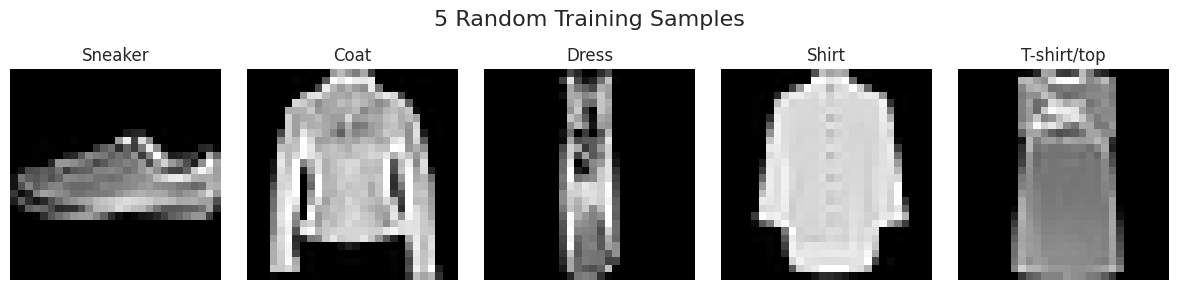


--- Visualizing a Batch Grid of 16 Images ---


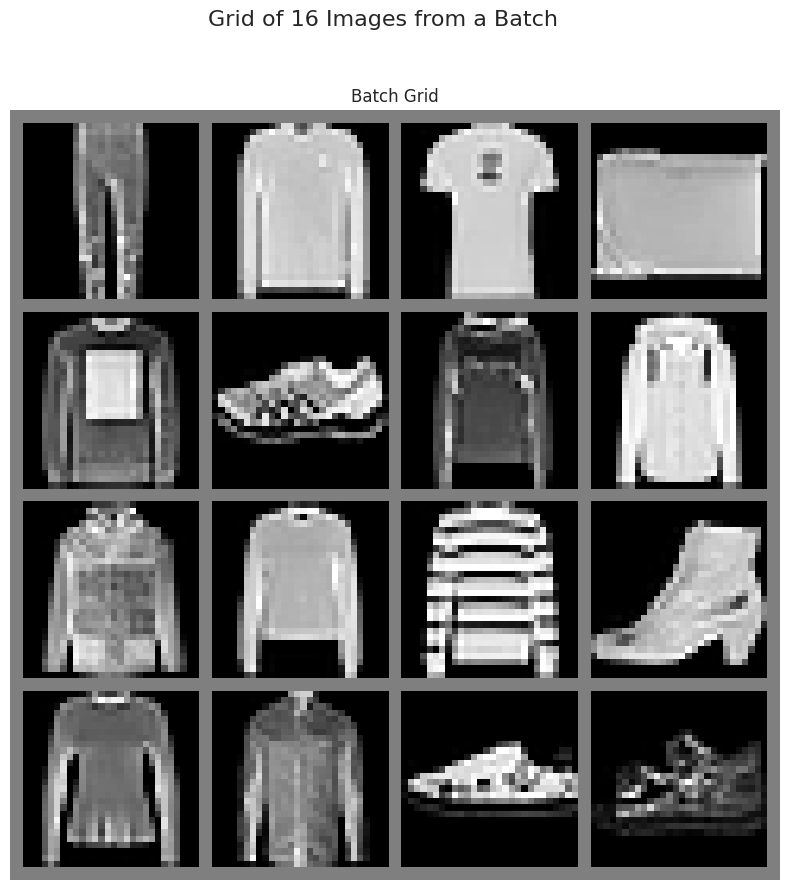

Labels for the 16 images in the grid:
Image 1: Trouser
Image 2: Pullover
Image 3: T-shirt/top
Image 4: Bag
Image 5: Pullover
Image 6: Sneaker
Image 7: Pullover
Image 8: Shirt
Image 9: Coat
Image 10: Pullover
Image 11: Pullover
Image 12: Ankle boot
Image 13: Pullover
Image 14: Shirt
Image 15: Sneaker
Image 16: Sandal


In [ ]:
# @title
# Import necessary libraries
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random

# --- 1) 下载训练集和测试集，创建 train_dataset、test_dataset、transform ---

# Define the transformation
# 1. Convert PIL Image to PyTorch Tensor (scales pixels to [0, 1])
# 2. Normalize pixel values from [0, 1] to [-1, 1] using mean=0.5, std=0.5
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download and load the training dataset
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',        # Directory to store the dataset
    train=True,           # This is the training set
    download=True,        # Download the dataset if it's not present
    transform=transform   # Apply the defined transformations
)

# Download and load the test dataset
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',        # Directory to store the dataset
    train=False,          # This is the test set
    download=True,        # Download the dataset if it's not present
    transform=transform   # Apply the defined transformations
)

# Define the device for training/inference (Colab T4 GPU or CPU)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# --- 2) 创建 train_loader 和 test_loader (batch_size=64) ---

batch_size = 64

# Create DataLoader for the training set
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,       # Shuffle training data for better generalization
    num_workers=2,      # Number of subprocesses to use for data loading
    pin_memory=True     # Copy Tensors into CUDA pinned memory for faster GPU transfer
)

# Create DataLoader for the test set
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,      # Do not shuffle test data (for deterministic evaluation)
    num_workers=2,
    pin_memory=True
)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")
print(f"Number of training batches (batch_size={batch_size}): {len(train_loader)}")
print(f"Number of test batches (batch_size={batch_size}): {len(test_loader)}")

# --- 3) 打印一个 batch 的 images.shape 与 labels.shape ---

# Get one batch of training data from the train_loader
dataiter = iter(train_loader)
images, labels = next(dataiter)

print(f"\nShape of images in one batch: {images.shape}") # Expected: [batch_size, channels, height, width] -> [64, 1, 28, 28]
print(f"Shape of labels in one batch: {labels.shape}")   # Expected: [batch_size] -> [64]

# --- 4) 可视化 5 张样本图和 16 张 batch 网格图 ---

# Helper function to display an image (denormalize and convert to numpy)
def imshow(img, title=None):
    # Denormalize: Reverse the normalization (img * std) + mean
    # FashionMNIST was normalized with mean=0.5, std=0.5. So, (img * 0.5) + 0.5 maps [-1, 1] to [0, 1].
    img = img * 0.5 + 0.5
    # Convert PyTorch Tensor to NumPy array
    npimg = img.numpy()
    # For grayscale (1 channel), matplotlib.pyplot.imshow expects (H, W) or (H, W, 1)
    # Transpose from (C, H, W) to (H, W, C) and then squeeze the channel dimension if it's 1.
    plt.imshow(np.transpose(npimg, (1, 2, 0)).squeeze(), cmap='gray') # Added cmap='gray' for clarity
    if title:
        plt.title(title)
    plt.axis('off') # Hide axes ticks and labels

# Fashion MNIST class labels for clearer visualization
FASHION_MNIST_LABELS = {
    0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
    5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'
}

print("\n--- Visualizing 5 Random Training Samples ---")

# Create a figure to display 5 random samples
plt.figure(figsize=(12, 3))
plt.suptitle('5 Random Training Samples', fontsize=16)

for i in range(5):
    # Pick a random index from the training dataset
    idx = random.randint(0, len(train_dataset) - 1)
    image, label = train_dataset[idx] # image is already transformed (tensor, normalized)

    plt.subplot(1, 5, i + 1)
    # FIX: label is already an int, so no need for .item()
    imshow(image, title=FASHION_MNIST_LABELS[label])
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

print("\n--- Visualizing a Batch Grid of 16 Images ---")

# Create a figure to display a grid of 16 images from the first batch
plt.figure(figsize=(10, 10))
plt.suptitle('Grid of 16 Images from a Batch', fontsize=16)

# Select the first 16 images and their labels from the batch
display_images = images[:16]
display_labels = labels[:16] # display_labels is a Tensor here

# Use torchvision.utils.make_grid to arrange the images into a grid
# make_grid expects (N, C, H, W) and outputs (C, H_grid, W_grid)
# normalize=False because our imshow function will handle denormalization from [-1, 1] to [0, 1]
grid_img = torchvision.utils.make_grid(display_images, nrow=4, padding=2, normalize=False)

# Display the grid image
imshow(grid_img, title='Batch Grid')
plt.show()

# Print labels for the 16 images in the grid for reference
print("Labels for the 16 images in the grid:")
for i, label_idx in enumerate(display_labels):
    # label_idx is a scalar tensor here, so .item() is appropriate
    print(f"Image {i+1}: {FASHION_MNIST_LABELS[label_idx.item()]}")

## Part 1.2: 定义模型并完成单 Batch 训练（MLP+CNN）


### Part 1.2 学习导航：同时搭建 MLP 和 CNN 两个模型

**这一部分在做什么？**
你将同时定义两个图像分类模型：`mlp_model` 和 `cnn_model`，输入都是 `28x28` 灰度图，输出都是 10 类分数（logits）。

**零基础理解：为什么要做两个模型？**
- `MLP`：把图片拉平成一维向量再分类，结构简单，便于入门。
- `CNN`：直接在二维图像上做卷积，更擅长提取局部空间特征。
- 同时实现两者可以帮助你直观理解“模型结构不同，学习效果也会不同”。

**📖 概念解释**
- **logits（逻辑值）**：模型输出的原始分数，未经 softmax。10 类分类就有 10 个数，数值越大表示模型越认为属于该类。

**输入 / 输出**
- 输入：来自 `DataLoader` 的图像张量
- 输出：`mlp_model` 与 `cnn_model` 的 10 类 logits 向量

**你在整条 pipeline 的位置**
这是“搭建大脑”阶段：先把两种常见模型都搭好，后续 Part 1.3 分别训练两者并对比效果。

![Part 1.3 MLP 结构图](https://commons.wikimedia.org/wiki/Special:FilePath/Artificial_neural_network.svg)

**图片讲解（你应该怎么读这张图）**
- 这张图对应 MLP 的思想：输入先展开成向量，再通过全连接层得到分类结果。
- MLP 的优点是结构直观，适合理解“输入-隐藏层-输出层”的基本概念。
- 但它会丢掉图像的二维空间邻接信息，这是它在图像任务中的局限之一。

![Part 1.3 CNN 结构图](https://commons.wikimedia.org/wiki/Special:FilePath/Typical_cnn.png)

**图片讲解（你应该怎么读这张图）**
- CNN 先做卷积与池化，逐层提取边缘、纹理、形状等局部特征。
- 之后再接全连接层输出 10 类分数。
- 对图像分类来说，CNN 通常比 MLP 更有效，Part 1.3 将分别训练两者并对比效果。

> 看图要点：MLP 更适合理解基础概念，CNN 更适合真正做图像识别任务。

**📖 训练相关概念解释**
- **loss（损失）**：衡量“预测”与“真实标签”差距的数值，越小说明预测越准。常用 CrossEntropyLoss 做分类。
- **optimizer（优化器）**：根据 loss 的梯度来更新模型参数的算法，如 SGD、Adam。负责“怎么改参数能让 loss 变小”。
- **criterion（损失函数）**：用来计算 loss 的函数，如 `nn.CrossEntropyLoss()`。
- **前向传播**：数据从输入层流到输出层，得到预测结果。
- **反向传播**：从 loss 往回算，得到每个参数的**梯度**（表示“往哪改、改多少能减小 loss”）。
- **参数更新**：`optimizer.step()` 根据梯度更新模型参数，完成一次学习。

**单 batch 训练核心步骤**
1. 前向传播：输入一个 batch → 模型输出预测。
2. 计算 loss：用 criterion 比较预测与真实标签。
3. 反向传播：`loss.backward()` 计算梯度。
4. 参数更新：`optimizer.step()` 根据梯度更新参数。

先跑 1 个 batch 的目的：验证训练链路和维度/设备是否完全正确，再进入后续完整训练。

**【你要做什么】**
基于已有环境，让 AI 在同一个 cell 里同时定义两个模型：`mlp_model` 与 `cnn_model`（输入 `28x28` 单通道，输出 `10` 类 logits），并打印两个模型结构。

**【衔接要求】**
不要重新创建 `DataLoader` 或重新下载数据；本步产出的 `mlp_model` 和 `cnn_model` 将在 Part 1.3 分别训练并对比效果。

**【通过标准】**
1. `mlp_model` 与 `cnn_model` 都成功定义并打印结构。
2. 单样本在两个模型上的前向推理都成功，输出维度正确。
3. 成功进行一次梯度更新并输出loss。

**时间建议：** 约 4 分钟。

建议在同一个代码 cell 内一次完成“定义 MLP/CNN + 仅用 CNN 做单 batch 训练验证”。
训练部分至少打印一次 loss，并给出更新前后 loss 对比图；变量名尽量保持可复用（如 `optimizer`、`criterion`）。

### 📋 可复制给 AI 的提示词（先复制，再按需微调）
我现在在做 Fashion MNIST 作业，当前进行到 Part 1.2（定义模型并完成单 Batch 训练）。
**运行环境说明：** 用户会把你生成的代码贴在「Part 1.1 的代码」之后执行，因此运行时已存在 `train_loader`、`test_loader`、`device`。请直接使用这些变量，不要在代码中再次下载数据或创建 DataLoader。
请在一个代码 cell 里完成：
1) 定义 `mlp_model`（输入展平后全连接）和 `cnn_model`（Conv+ReLU+Pool+FC），输出都为 10 类；
2) 打印两个模型结构；
3) 只使用 `cnn_model` 跑 1 个 batch 的训练步骤（前向、loss、反向、参数更新）；
4) 画更新前后 loss 对比。
**【重要】** 所有图表必须使用英文，防止中文乱码。
要求：变量名使用 `mlp_model` 与 `cnn_model`；优化器绑定 `cnn_model.parameters()`；训练统一使用 Colab T4 GPU（cuda）；请只输出可直接运行的纯 Python 代码，保留少量中文注释，不要输出解释文字。

**👨‍💻 请在下方 AI prompt cell 中填写 prompt，并将 AI 生成代码粘贴到后面的 Code cell 运行。**

In [ ]:
# @title AI prompt cell

import ipywidgets as widgets
from IPython.display import display, HTML, Markdown,clear_output
from google.colab import ai

dropdown = widgets.Dropdown(
    options=[],
    layout={'width': 'auto'}
)

def update_model_list(new_options):
    dropdown.options = new_options
update_model_list(ai.list_models())

text_input = widgets.Textarea(
    placeholder='Ask me anything....',
    layout={'width': 'auto', 'height': '100px'},
)

button = widgets.Button(
    description='Submit Text',
    disabled=False,
    tooltip='Click to submit the text',
    icon='check'
)

output_area = widgets.Output(
     layout={'width': 'auto', 'max_height': '300px','overflow_y': 'scroll'}
)

def on_button_clicked(b):
    with output_area:
        output_area.clear_output(wait=False)
        accumulated_content = ""
        for new_chunk in ai.generate_text(prompt=text_input.value, model_name=dropdown.value, stream=True):
            if new_chunk is None:
                continue
            accumulated_content += new_chunk
            clear_output(wait=True)
            display(Markdown(accumulated_content))

button.on_click(on_button_clicked)
vbox = widgets.GridBox([dropdown, text_input, button, output_area])

display(HTML("""
<style>
.widget-dropdown select {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
.widget-textarea textarea {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
</style>
"""))
display(vbox)


GridBox(children=(Dropdown(layout=Layout(width='auto'), options=('google/gemini-2.5-flash', 'google/gemini-2.5…

--- MLP Model Structure ---
MLPModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc_layers): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

--- CNN Model Structure ---
CNNModel(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc_layers): Sequential(
    (0): Linear(in_features=3136, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)
--------------------------

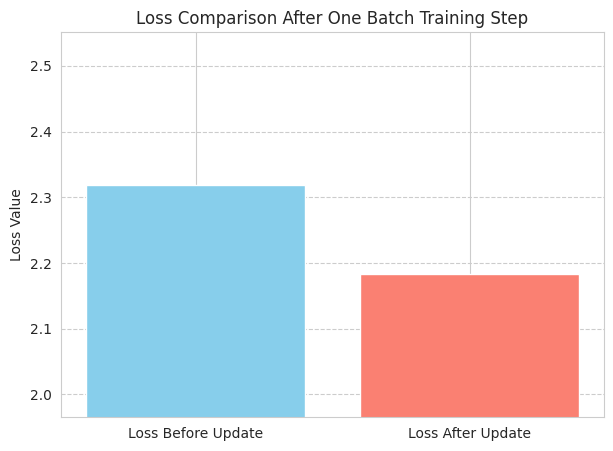

In [ ]:
# @title
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# --- 1. 定义 mlp_model 和 cnn_model ---

# 定义 MLP 模型
class MLPModel(nn.Module):
    def __init__(self):
        super(MLPModel, self).__init__()
        self.flatten = nn.Flatten()
        self.fc_layers = nn.Sequential(
            nn.Linear(28 * 28, 256),  # 输入 28x28 = 784
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)       # 输出 10 类
        )

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc_layers(x)
        return x

# 定义 CNN 模型
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv_layers = nn.Sequential(
            # Conv Layer 1: 1 input channel, 32 output channels, 3x3 kernel, 1 padding
            # Input: (Batch_size, 1, 28, 28) -> Output: (Batch_size, 32, 28, 28)
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            # Max Pooling 1: 2x2 kernel, stride 2
            # Input: (Batch_size, 32, 28, 28) -> Output: (Batch_size, 32, 14, 14)
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer 2: 32 input channels, 64 output channels, 3x3 kernel, 1 padding
            # Input: (Batch_size, 32, 14, 14) -> Output: (Batch_size, 64, 14, 14)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            # Max Pooling 2: 2x2 kernel, stride 2
            # Input: (Batch_size, 64, 14, 14) -> Output: (Batch_size, 64, 7, 7)
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.flatten = nn.Flatten()
        # Fully Connected Layers
        # Input to FC layer: 64 channels * 7 * 7 = 3136 features
        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)       # 输出 10 类
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.flatten(x)
        x = self.fc_layers(x)
        return x

# 实例化模型并将其移动到 'device' (假定 device 已在 Part 1.1 定义)
mlp_model = MLPModel().to(device)
cnn_model = CNNModel().to(device)

# --- 2. 打印两个模型结构 ---
print("--- MLP Model Structure ---")
print(mlp_model)
print("\n--- CNN Model Structure ---")
print(cnn_model)
print("-" * 30)


# --- 3. 只使用 cnn_model 跑 1 个 batch 的训练步骤 ---

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

# 获取一个 batch 的数据
data_iter = iter(train_loader)
images, labels = next(data_iter)

# 将数据移动到 'device'
images = images.to(device)
labels = labels.to(device)

# --- 计算更新前的 Loss ---
cnn_model.eval() # 设置为评估模式，不计算梯度，不更新参数
with torch.no_grad():
    outputs_before = cnn_model(images)
    loss_before = criterion(outputs_before, labels).item()

print(f"\nLoss before update: {loss_before:.4f}")

# --- 训练步骤 ---
cnn_model.train() # 设置为训练模式
optimizer.zero_grad() # 梯度清零
outputs = cnn_model(images) # 前向传播
loss = criterion(outputs, labels) # 计算 Loss
loss.backward() # 反向传播，计算梯度
optimizer.step() # 参数更新

# --- 计算更新后的 Loss ---
cnn_model.eval() # 再次设置为评估模式
with torch.no_grad():
    outputs_after = cnn_model(images)
    loss_after = criterion(outputs_after, labels).item()

print(f"Loss after update: {loss_after:.4f}")


# --- 4. 画更新前后 loss 对比图 ---
plt.figure(figsize=(7, 5))
plt.bar(['Loss Before Update', 'Loss After Update'], [loss_before, loss_after], color=['skyblue', 'salmon'])
plt.ylabel('Loss Value')
plt.title('Loss Comparison After One Batch Training Step')
plt.grid(axis='y', linestyle='--')
plt.ylim(min(loss_before, loss_after) * 0.9, max(loss_before, loss_after) * 1.1) # 调整Y轴范围，使其更清晰
plt.show()

Using device: cuda
Number of training samples: 60000
Number of test samples: 10000
Number of training batches (batch_size=64): 938
Number of test batches (batch_size=64): 157

Shape of images in one batch: torch.Size([64, 1, 28, 28])
Shape of labels in one batch: torch.Size([64])

--- Visualizing 5 Random Training Samples ---


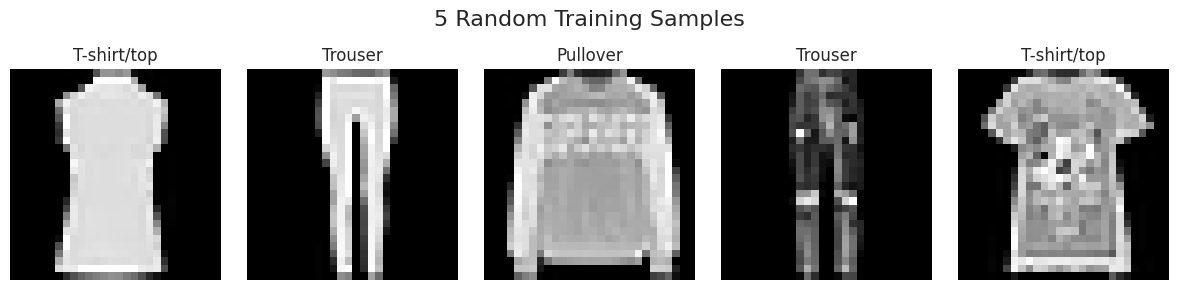


--- Visualizing a Batch Grid of 16 Images ---


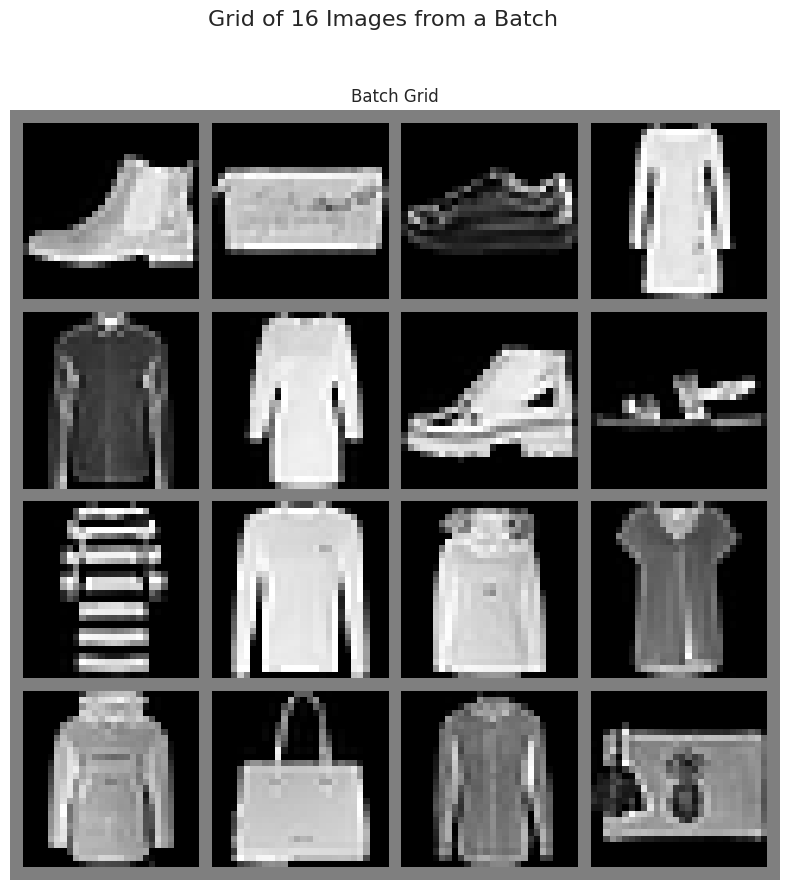

Labels for the 16 images in the grid:
Image 1: Ankle boot
Image 2: Bag
Image 3: Sneaker
Image 4: Dress
Image 5: Shirt
Image 6: Dress
Image 7: Ankle boot
Image 8: Sandal
Image 9: Dress
Image 10: Pullover
Image 11: Coat
Image 12: Shirt
Image 13: Coat
Image 14: Bag
Image 15: Shirt
Image 16: Bag
--- MLP Model Structure ---
MLPModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc_layers): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

--- CNN Model Structure ---
CNNModel(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride

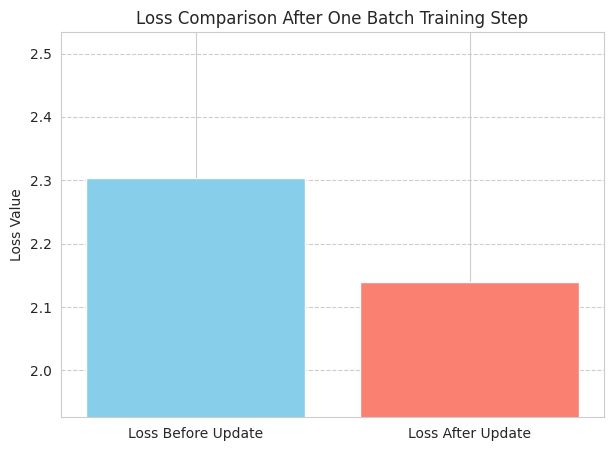

In [ ]:
# @title
# Import necessary libraries
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random

# --- 1) 下载训练集和测试集，创建 train_dataset、test_dataset、transform ---

# Define the transformation
# 1. Convert PIL Image to PyTorch Tensor (scales pixels to [0, 1])
# 2. Normalize pixel values from [0, 1] to [-1, 1] using mean=0.5, std=0.5
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download and load the training dataset
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',        # Directory to store the dataset
    train=True,           # This is the training set
    download=True,        # Download the dataset if it's not present
    transform=transform   # Apply the defined transformations
)

# Download and load the test dataset
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',        # Directory to store the dataset
    train=False,          # This is the test set
    download=True,        # Download the dataset if it's not present
    transform=transform   # Apply the defined transformations
)

# Define the device for training/inference (Colab T4 GPU or CPU)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# --- 2) 创建 train_loader 和 test_loader (batch_size=64) ---

batch_size = 64

# Create DataLoader for the training set
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,       # Shuffle training data for better generalization
    num_workers=2,      # Number of subprocesses to use for data loading
    pin_memory=True     # Copy Tensors into CUDA pinned memory for faster GPU transfer
)

# Create DataLoader for the test set
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,      # Do not shuffle test data (for deterministic evaluation)
    num_workers=2,
    pin_memory=True
)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")
print(f"Number of training batches (batch_size={batch_size}): {len(train_loader)}")
print(f"Number of test batches (batch_size={batch_size}): {len(test_loader)}")

# --- 3) 打印一个 batch 的 images.shape 与 labels.shape ---

# Get one batch of training data from the train_loader
dataiter = iter(train_loader)
images, labels = next(dataiter)

print(f"\nShape of images in one batch: {images.shape}") # Expected: [batch_size, channels, height, width] -> [64, 1, 28, 28]
print(f"Shape of labels in one batch: {labels.shape}")   # Expected: [batch_size] -> [64]

# --- 4) 可视化 5 张样本图和 16 张 batch 网格图 ---

# Helper function to display an image (denormalize and convert to numpy)
def imshow(img, title=None):
    # Denormalize: Reverse the normalization (img * std) + mean
    # FashionMNIST was normalized with mean=0.5, std=0.5. So, (img * 0.5) + 0.5 maps [-1, 1] to [0, 1].
    img = img * 0.5 + 0.5
    # Convert PyTorch Tensor to NumPy array
    npimg = img.numpy()
    # For grayscale (1 channel), matplotlib.pyplot.imshow expects (H, W) or (H, W, 1)
    # Transpose from (C, H, W) to (H, W, C) and then squeeze the channel dimension if it's 1.
    plt.imshow(np.transpose(npimg, (1, 2, 0)).squeeze(), cmap='gray') # Added cmap='gray' for clarity
    if title:
        plt.title(title)
    plt.axis('off') # Hide axes ticks and labels

# Fashion MNIST class labels for clearer visualization
FASHION_MNIST_LABELS = {
    0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
    5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'
}

print("\n--- Visualizing 5 Random Training Samples ---")

# Create a figure to display 5 random samples
plt.figure(figsize=(12, 3))
plt.suptitle('5 Random Training Samples', fontsize=16)

for i in range(5):
    # Pick a random index from the training dataset
    idx = random.randint(0, len(train_dataset) - 1)
    image, label = train_dataset[idx] # image is already transformed (tensor, normalized)

    plt.subplot(1, 5, i + 1)
    # FIX: label is already an int, so no need for .item()
    imshow(image, title=FASHION_MNIST_LABELS[label])
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

print("\n--- Visualizing a Batch Grid of 16 Images ---")

# Create a figure to display a grid of 16 images from the first batch
plt.figure(figsize=(10, 10))
plt.suptitle('Grid of 16 Images from a Batch', fontsize=16)

# Select the first 16 images and their labels from the batch
display_images = images[:16]
display_labels = labels[:16] # display_labels is a Tensor here

# Use torchvision.utils.make_grid to arrange the images into a grid
# make_grid expects (N, C, H, W) and outputs (C, H_grid, W_grid)
# normalize=False because our imshow function will handle denormalization from [-1, 1] to [0, 1]
grid_img = torchvision.utils.make_grid(display_images, nrow=4, padding=2, normalize=False)

# Display the grid image
imshow(grid_img, title='Batch Grid')
plt.show()

# Print labels for the 16 images in the grid for reference
print("Labels for the 16 images in the grid:")
for i, label_idx in enumerate(display_labels):
    # label_idx is a scalar tensor here, so .item() is appropriate
    print(f"Image {i+1}: {FASHION_MNIST_LABELS[label_idx.item()]}")

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# --- 1. 定义 mlp_model 和 cnn_model ---

# 定义 MLP 模型
class MLPModel(nn.Module):
    def __init__(self):
        super(MLPModel, self).__init__()
        self.flatten = nn.Flatten()
        self.fc_layers = nn.Sequential(
            nn.Linear(28 * 28, 256),  # 输入 28x28 = 784
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)       # 输出 10 类
        )

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc_layers(x)
        return x

# 定义 CNN 模型
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv_layers = nn.Sequential(
            # Conv Layer 1: 1 input channel, 32 output channels, 3x3 kernel, 1 padding
            # Input: (Batch_size, 1, 28, 28) -> Output: (Batch_size, 32, 28, 28)
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            # Max Pooling 1: 2x2 kernel, stride 2
            # Input: (Batch_size, 32, 28, 28) -> Output: (Batch_size, 32, 14, 14)
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer 2: 32 input channels, 64 output channels, 3x3 kernel, 1 padding
            # Input: (Batch_size, 32, 14, 14) -> Output: (Batch_size, 64, 14, 14)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            # Max Pooling 2: 2x2 kernel, stride 2
            # Input: (Batch_size, 64, 14, 14) -> Output: (Batch_size, 64, 7, 7)
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.flatten = nn.Flatten()
        # Fully Connected Layers
        # Input to FC layer: 64 channels * 7 * 7 = 3136 features
        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)       # 输出 10 类
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.flatten(x)
        x = self.fc_layers(x)
        return x

# 实例化模型并将其移动到 'device' (假定 device 已在 Part 1.1 定义)
mlp_model = MLPModel().to(device)
cnn_model = CNNModel().to(device)

# --- 2. 打印两个模型结构 ---
print("--- MLP Model Structure ---")
print(mlp_model)
print("\n--- CNN Model Structure ---")
print(cnn_model)
print("-" * 30)


# --- 3. 只使用 cnn_model 跑 1 个 batch 的训练步骤 ---

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

# 获取一个 batch 的数据
data_iter = iter(train_loader)
images, labels = next(data_iter)

# 将数据移动到 'device'
images = images.to(device)
labels = labels.to(device)

# --- 计算更新前的 Loss ---
cnn_model.eval() # 设置为评估模式，不计算梯度，不更新参数
with torch.no_grad():
    outputs_before = cnn_model(images)
    loss_before = criterion(outputs_before, labels).item()

print(f"\nLoss before update: {loss_before:.4f}")

# --- 训练步骤 ---
cnn_model.train() # 设置为训练模式
optimizer.zero_grad() # 梯度清零
outputs = cnn_model(images) # 前向传播
loss = criterion(outputs, labels) # 计算 Loss
loss.backward() # 反向传播，计算梯度
optimizer.step() # 参数更新

# --- 计算更新后的 Loss ---
cnn_model.eval() # 再次设置为评估模式
with torch.no_grad():
    outputs_after = cnn_model(images)
    loss_after = criterion(outputs_after, labels).item()

print(f"Loss after update: {loss_after:.4f}")


# --- 4. 画更新前后 loss 对比图 ---
plt.figure(figsize=(7, 5))
plt.bar(['Loss Before Update', 'Loss After Update'], [loss_before, loss_after], color=['skyblue', 'salmon'])
plt.ylabel('Loss Value')
plt.title('Loss Comparison After One Batch Training Step')
plt.grid(axis='y', linestyle='--')
plt.ylim(min(loss_before, loss_after) * 0.9, max(loss_before, loss_after) * 1.1) # 调整Y轴范围，使其更清晰
plt.show()

**🛠️ Debug 环节 (如果报错)：**
这一步常见问题是 `forward` 里维度不匹配，或 `view/reshape` 写错。把完整报错信息和代码一起发给 AI，让它逐行解释并修复。

* **请在下方的 Debug Prompt Cell 中记录你发给 AI 的排错指令。**
* **请将 AI 修改后的代码粘贴到下方的 Debug Code Cell 中运行。**（如果一次就跑通了，这里可以留空）

In [ ]:
# @title Debug prompt cell

import ipywidgets as widgets
from IPython.display import display, HTML, Markdown,clear_output
from google.colab import ai

dropdown = widgets.Dropdown(
    options=[],
    layout={'width': 'auto'}
)

def update_model_list(new_options):
    dropdown.options = new_options
update_model_list(ai.list_models())

text_input = widgets.Textarea(
    placeholder='Ask me anything....',
    layout={'width': 'auto', 'height': '100px'},
)

button = widgets.Button(
    description='Submit Text',
    disabled=False,
    tooltip='Click to submit the text',
    icon='check'
)

output_area = widgets.Output(
     layout={'width': 'auto', 'max_height': '300px','overflow_y': 'scroll'}
)

def on_button_clicked(b):
    with output_area:
        output_area.clear_output(wait=False)
        accumulated_content = ""
        for new_chunk in ai.generate_text(prompt=text_input.value, model_name=dropdown.value, stream=True):
            if new_chunk is None:
                continue
            accumulated_content += new_chunk
            clear_output(wait=True)
            display(Markdown(accumulated_content))

button.on_click(on_button_clicked)
vbox = widgets.GridBox([dropdown, text_input, button, output_area])

display(HTML("""
<style>
.widget-dropdown select {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
.widget-textarea textarea {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
</style>
"""))
display(vbox)


## Part 1.3: 使用 MLP 和 CNN 训练并对比效果


### Part 1.3 学习导航：从“会训练”到“会对比”

**📖 概念解释**
- **step（步 / 迭代）**：每用 1 个 batch 做一次“前向→算 loss→反向→更新参数”，就是 1 个 step。训练 100 个 batch = 做 100 个 steps。
- **epoch（轮）**：遍历完整个训练集一遍，称为 1 个 epoch。例如 60000 张图、batch_size=64，则 1 epoch ≈ 938 个 steps。
- **accuracy（准确率）**：预测正确的样本数 ÷ 总样本数。例如 100 张测试图中预测对 85 张，accuracy = 85%。

**这一部分在做什么？**
你会分别对 `mlp_model` 和 `cnn_model` 各训练 10 个 epoch，记录两者的 loss 变化；然后在测试集上分别计算 accuracy，**对比 MLP 与 CNN 的训练效果**。

**为什么要对比两个模型？**
Part 1.2 已同时定义了 MLP 和 CNN，通过实际训练对比可以直观看到：CNN 在图像任务上通常优于 MLP。

**输入 / 输出**
- 输入：Part 1.2 的 `mlp_model`、`cnn_model`、`train_loader`、`test_loader`（需为两个模型分别创建 optimizer 和 criterion）
- 输出：两个模型的 loss 曲线、测试集 accuracy、MLP vs CNN 对比图

**你在整条 pipeline 的位置**
这是“训练 + 对比评估”阶段，属于完整训练闭环里的核心环节。

**【你要做什么】**
基于 Part 1.2 已有的 `mlp_model`、`cnn_model`、`train_loader`、`test_loader`，**分别**对两个模型各训练 5 个 epoch（每个模型需各自的 optimizer），记录 loss；训练后分别计算测试集 accuracy，**绘制 MLP vs CNN 的 loss 对比曲线**，并打印两个模型的最终准确率对比。

**【可视化验证（建议必须做）】**
请在代码中记录每个 batch 的指标，并画图：
- MLP 与 CNN 的 loss 曲线对比（同一张图，两条线）
- 打印 MLP 和 CNN 的最终测试准确率对比
这样能直观看到 CNN 在图像任务上的优势。

**【衔接要求】**
**直接使用** Part 1.2 已定义的 `mlp_model`、`cnn_model`，**不要重新定义模型**；直接使用 Part 1.1 的 `train_loader`、`test_loader`，**不要重复下载数据**；只编写训练与对比流程，确保模型与数据都在 Colab T4 GPU（cuda）上。

**【通过标准】**
1. MLP 和 CNN 各 5 个 epoch 能完整跑完。
2. 打印两个模型的最终测试准确率。
3. 至少有 1 张 MLP vs CNN 的 loss 对比曲线图。

**时间建议：** 约 5 分钟。

### 📋 可复制给 AI 的提示词（先复制，再按需微调）
我现在在做 Fashion MNIST 作业，当前进行到 Part 1.3（MLP 与 CNN 训练对比）。
**运行环境说明：** 用户会按顺序运行 notebook，执行本段代码时环境中已存在 `mlp_model`、`cnn_model`、`train_loader`、`test_loader`、`device`。请直接使用这些变量，不要在代码中重新定义模型或下载数据。
请完成：
1) 分别对 `mlp_model` 和 `cnn_model` 各训练 5 个 epoch（各自创建 optimizer），记录两者的 loss；
2) 训练后分别计算两个模型在测试集上的 accuracy；
3) 绘制 MLP vs CNN 的 loss 对比曲线（同一张图），并打印两个模型的准确率对比。
**【重要】** 所有图表必须使用英文，防止中文乱码。使用 Colab T4 GPU（cuda）。

**👨‍💻 请在下方 AI prompt cell 中填写 prompt，并将 AI 生成代码粘贴到后面的 Code cell 运行。**

In [ ]:
# @title AI prompt cell

import ipywidgets as widgets
from IPython.display import display, HTML, Markdown,clear_output
from google.colab import ai

dropdown = widgets.Dropdown(
    options=[],
    layout={'width': 'auto'}
)

def update_model_list(new_options):
    dropdown.options = new_options
update_model_list(ai.list_models())

text_input = widgets.Textarea(
    placeholder='Ask me anything....',
    layout={'width': 'auto', 'height': '100px'},
)

button = widgets.Button(
    description='Submit Text',
    disabled=False,
    tooltip='Click to submit the text',
    icon='check'
)

output_area = widgets.Output(
     layout={'width': 'auto', 'max_height': '300px','overflow_y': 'scroll'}
)

def on_button_clicked(b):
    with output_area:
        output_area.clear_output(wait=False)
        accumulated_content = ""
        for new_chunk in ai.generate_text(prompt=text_input.value, model_name=dropdown.value, stream=True):
            if new_chunk is None:
                continue
            accumulated_content += new_chunk
            clear_output(wait=True)
            display(Markdown(accumulated_content))

button.on_click(on_button_clicked)
vbox = widgets.GridBox([dropdown, text_input, button, output_area])

display(HTML("""
<style>
.widget-dropdown select {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
.widget-textarea textarea {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
</style>
"""))
display(vbox)


GridBox(children=(Dropdown(layout=Layout(width='auto'), options=('google/gemini-2.5-flash', 'google/gemini-2.5…

Using device: cuda

--- Starting MLP Model Training ---
MLP Epoch 1/5, Training Loss: 0.4962
MLP Epoch 2/5, Training Loss: 0.3701
MLP Epoch 3/5, Training Loss: 0.3323
MLP Epoch 4/5, Training Loss: 0.3063
MLP Epoch 5/5, Training Loss: 0.2869
MLP Training finished in 69.85 seconds.

--- Starting CNN Model Training ---
CNN Epoch 1/5, Training Loss: 0.4319
CNN Epoch 2/5, Training Loss: 0.2757
CNN Epoch 3/5, Training Loss: 0.2299
CNN Epoch 4/5, Training Loss: 0.2015
CNN Epoch 5/5, Training Loss: 0.1743
CNN Training finished in 71.52 seconds.

--- Evaluating Models on Test Set ---
MLP Test Accuracy: 87.34%
CNN Test Accuracy: 91.51%

--- Generating Loss Comparison Plot ---


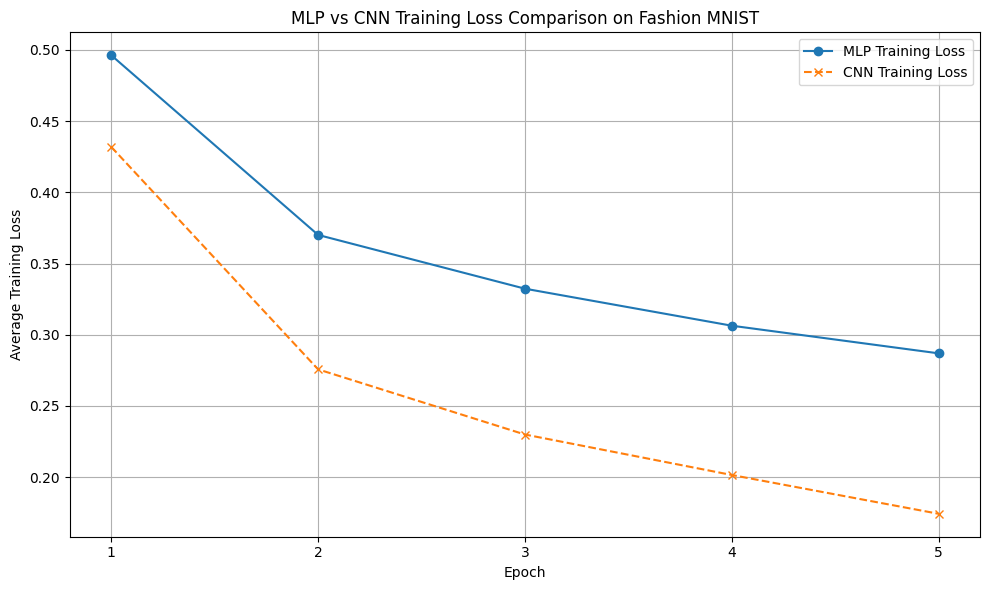


--- Accuracy Comparison ---
MLP Test Accuracy: 87.34%
CNN Test Accuracy: 91.51%


In [ ]:
# @title
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import time

# Ensure matplotlib uses a non-interactive backend if running in a script without display
# plt.switch_backend('Agg') # Uncomment this if you face issues with display in a non-GUI environment

print(f"Using device: {device}")

# Hyperparameters
num_epochs = 5
learning_rate = 0.001

# Loss function
criterion = nn.CrossEntropyLoss()

# --- MLP Model Training ---
print("\n--- Starting MLP Model Training ---")
# Create a new optimizer specifically for mlp_model
optimizer_mlp = optim.Adam(mlp_model.parameters(), lr=learning_rate)
mlp_losses = []

mlp_model.train() # Set the model to training mode
start_time_mlp = time.time()

for epoch in range(num_epochs):
    running_loss_mlp = 0.0
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        # Assuming mlp_model's forward method handles flattening (e.g., x.view(-1, 28*28))
        outputs = mlp_model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer_mlp.zero_grad()
        loss.backward()
        optimizer_mlp.step()

        running_loss_mlp += loss.item() * images.size(0) # Accumulate batch loss weighted by batch size

    epoch_loss_mlp = running_loss_mlp / len(train_loader.dataset) # Average loss over the epoch
    mlp_losses.append(epoch_loss_mlp)
    print(f"MLP Epoch {epoch+1}/{num_epochs}, Training Loss: {epoch_loss_mlp:.4f}")

end_time_mlp = time.time()
print(f"MLP Training finished in {end_time_mlp - start_time_mlp:.2f} seconds.")


# --- CNN Model Training ---
print("\n--- Starting CNN Model Training ---")
# Create a new optimizer specifically for cnn_model
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=learning_rate)
cnn_losses = []

cnn_model.train() # Set the model to training mode
start_time_cnn = time.time()

for epoch in range(num_epochs):
    running_loss_cnn = 0.0
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device) # CNN expects (batch_size, channels, height, width)
        labels = labels.to(device)

        # Forward pass
        outputs = cnn_model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer_cnn.zero_grad()
        loss.backward()
        optimizer_cnn.step()

        running_loss_cnn += loss.item() * images.size(0) # Accumulate batch loss weighted by batch size

    epoch_loss_cnn = running_loss_cnn / len(train_loader.dataset) # Average loss over the epoch
    cnn_losses.append(epoch_loss_cnn)
    print(f"CNN Epoch {epoch+1}/{num_epochs}, Training Loss: {epoch_loss_cnn:.4f}")

end_time_cnn = time.time()
print(f"CNN Training finished in {end_time_cnn - start_time_cnn:.2f} seconds.")


# --- Model Evaluation on Test Set ---
print("\n--- Evaluating Models on Test Set ---")

# Evaluate MLP Model
mlp_model.eval() # Set the model to evaluation mode
correct_mlp = 0
total_mlp = 0
with torch.no_grad(): # Disable gradient calculation for inference
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = mlp_model(images)
        _, predicted = torch.max(outputs.data, 1) # Get the class with the highest probability
        total_mlp += labels.size(0)
        correct_mlp += (predicted == labels).sum().item()

accuracy_mlp = 100 * correct_mlp / total_mlp
print(f"MLP Test Accuracy: {accuracy_mlp:.2f}%")

# Evaluate CNN Model
cnn_model.eval() # Set the model to evaluation mode
correct_cnn = 0
total_cnn = 0
with torch.no_grad(): # Disable gradient calculation for inference
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = cnn_model(images)
        _, predicted = torch.max(outputs.data, 1) # Get the class with the highest probability
        total_cnn += labels.size(0)
        correct_cnn += (predicted == labels).sum().item()

accuracy_cnn = 100 * correct_cnn / total_cnn
print(f"CNN Test Accuracy: {accuracy_cnn:.2f}%")


# --- Plotting Loss Comparison ---
print("\n--- Generating Loss Comparison Plot ---")
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), mlp_losses, label='MLP Training Loss', marker='o', linestyle='-')
plt.plot(range(1, num_epochs + 1), cnn_losses, label='CNN Training Loss', marker='x', linestyle='--')
plt.title('MLP vs CNN Training Loss Comparison on Fashion MNIST')
plt.xlabel('Epoch')
plt.ylabel('Average Training Loss')
plt.legend()
plt.grid(True)
plt.xticks(range(1, num_epochs + 1)) # Ensure x-axis ticks are integer epochs
plt.tight_layout()
plt.show()

# --- Print Accuracy Comparison ---
print("\n--- Accuracy Comparison ---")
print(f"MLP Test Accuracy: {accuracy_mlp:.2f}%")
print(f"CNN Test Accuracy: {accuracy_cnn:.2f}%")

**🛠️ Debug 环节 (如果报错)：**
完整训练时最容易出现变量没衔接上（例如模型名/优化器名不一致）、测试阶段忘记 `model.eval()` 等问题。把错误原文、关键代码和你预期结果一起发给 AI。

* **请在下方的 Debug Prompt Cell 中记录你发给 AI 的排错指令。**
* **请将 AI 修改后的代码粘贴到下方的 Debug Code Cell 中运行。**（如果一次就跑通了，这里可以留空）

In [ ]:
# @title Debug prompt cell

import ipywidgets as widgets
from IPython.display import display, HTML, Markdown,clear_output
from google.colab import ai

dropdown = widgets.Dropdown(
    options=[],
    layout={'width': 'auto'}
)

def update_model_list(new_options):
    dropdown.options = new_options
update_model_list(ai.list_models())

text_input = widgets.Textarea(
    placeholder='Ask me anything....',
    layout={'width': 'auto', 'height': '100px'},
)

button = widgets.Button(
    description='Submit Text',
    disabled=False,
    tooltip='Click to submit the text',
    icon='check'
)

output_area = widgets.Output(
     layout={'width': 'auto', 'max_height': '300px','overflow_y': 'scroll'}
)

def on_button_clicked(b):
    with output_area:
        output_area.clear_output(wait=False)
        accumulated_content = ""
        for new_chunk in ai.generate_text(prompt=text_input.value, model_name=dropdown.value, stream=True):
            if new_chunk is None:
                continue
            accumulated_content += new_chunk
            clear_output(wait=True)
            display(Markdown(accumulated_content))

button.on_click(on_button_clicked)
vbox = widgets.GridBox([dropdown, text_input, button, output_area])

display(HTML("""
<style>
.widget-dropdown select {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
.widget-textarea textarea {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
</style>
"""))
display(vbox)


## 附加挑战（可选）: 探索超参数对训练效果的影响


### 附加挑战学习导航：我们在做“调参实验”

**📖 概念解释**
- **超参数**：需要人为设定的参数（如学习率、batch_size、epoch 数），区别于模型从数据中“学”到的参数（如权重、偏置）。
- **学习率（lr）**：控制每次参数更新的步长。太大：loss 可能震荡不收敛；太小：收敛很慢。常见范围 1e-4 ~ 1e-1。
- **epoch 数**：训练时遍历整个训练集多少轮。epoch 越多训练越久，但过多可能过拟合。
- **dropout**：随机“丢弃”一部分神经元，是一种正则化手段，有助于减轻过拟合。

**这一部分在做什么？**
前面你已经让模型能跑通训练流程了。现在我们要做的是像做科学实验一样，**每次只改一个条件**（例如学习率、batch size、优化器），观察模型表现会怎样变化。

**为什么要做这一步？**
同一份代码，超参数不同，结果会差很多。调参的目标不是“蒙对”，而是建立一种可复现的实验习惯。

**输入 / 输出**
- 输入：`model`、`train_loader`、`test_loader`、训练代码框架
- 输出：不同超参数组合的对比结果（表格+图）和你的结论

**你在整条 pipeline 的位置**
这是“模型优化”阶段：在“能训练”之后，进一步提升效果与稳定性。

**注意点**
- 你可以重点看：哪条曲线更稳定、哪条最终指标更高、哪条容易震荡。
- 例如学习率太大可能震荡，太小又收敛慢；正则化太强可能欠拟合。
- 调参的目标不是单次最优，而是在稳定性、速度、精度之间找平衡点。

> 小提醒：最常见的错误是一次改太多参数，导致不知道结果变化由谁引起。每轮尽量只改 1~2 个变量。

**【你要做什么】**
这是开放式任务（给有余力同学）：让 AI 帮你设计并执行“小型对比实验”，理解不同超参数对模型训练和测试表现的影响。

**【建议可选超参数】**
你可以从以下项目里任选 1~4 个做实验：
- 学习率（`lr`）
- batch size（`batch_size`）
- 优化器类型（SGD / Adam）
- epoch 数
- 网络宽度（隐藏层神经元数）
- 是否使用 dropout 及其比例

**【实验要求】**
1. 先让 AI 设计实验方案（例如每次只改一个变量，其他保持不变）。
2. 自动运行多组实验并记录结果。
3. 输出结构化结果表（如 DataFrame）。
4. 绘制可视化图（折线图/柱状图均可），并对结果做简短结论。

**【衔接要求】**
基于前面 Part 1.1~1.3 的代码环境继续，不要重开一套流程；优先复用数据和训练函数。

**【通过标准】**
1. 至少完成 3 组超参数实验。
2. 至少输出 1 张对比可视化图。
3. 能说明“哪个超参数变化带来了什么影响”。

**时间建议：** 5~10 分钟（附加题，不强制）。

### 📋 可复制给 AI 的提示词（先复制，再按需微调）
我现在在做 Fashion MNIST 作业的附加挑战（超参数实验）。
**运行环境说明：** 用户会按顺序运行 notebook，执行本段代码时环境中已存在 `train_loader`、`test_loader`、`mlp_model`、`cnn_model`、`device` 等。请直接使用这些变量，不要在代码中重新下载数据或定义模型。
请设计并执行对比实验：从 3 组超参数组合（如学习率、batch size、优化器、隐藏层宽度等）选取一组，输出结构化结果表（DataFrame），并绘制可视化图（折线图或柱状图），最后给出简短结论。**【重要】** 所有图表必须使用英文，防止中文乱码。使用 Colab T4 GPU（cuda）。

**👨‍💻 请在下方 AI prompt cell 中填写 prompt，并将 AI 生成代码粘贴到后面的 Code cell 运行。**

In [ ]:
# @title AI prompt cell

import ipywidgets as widgets
from IPython.display import display, HTML, Markdown,clear_output
from google.colab import ai

dropdown = widgets.Dropdown(
    options=[],
    layout={'width': 'auto'}
)

def update_model_list(new_options):
    dropdown.options = new_options
update_model_list(ai.list_models())

text_input = widgets.Textarea(
    placeholder='Ask me anything....',
    layout={'width': 'auto', 'height': '100px'},
)

button = widgets.Button(
    description='Submit Text',
    disabled=False,
    tooltip='Click to submit the text',
    icon='check'
)

output_area = widgets.Output(
     layout={'width': 'auto', 'max_height': '300px','overflow_y': 'scroll'}
)

def on_button_clicked(b):
    with output_area:
        output_area.clear_output(wait=False)
        accumulated_content = ""
        for new_chunk in ai.generate_text(prompt=text_input.value, model_name=dropdown.value, stream=True):
            if new_chunk is None:
                continue
            accumulated_content += new_chunk
            clear_output(wait=True)
            display(Markdown(accumulated_content))

button.on_click(on_button_clicked)
vbox = widgets.GridBox([dropdown, text_input, button, output_area])

display(HTML("""
<style>
.widget-dropdown select {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
.widget-textarea textarea {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
</style>
"""))
display(vbox)


GridBox(children=(Dropdown(layout=Layout(width='auto'), options=('google/gemini-2.5-flash', 'google/gemini-2.5…


--- Starting Adam_LR0.001 ---


Epoch 1/10 Training:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 1/10 Testing:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 1: Train Loss=0.4866, Train Acc=82.40%, Test Loss=0.4504, Test Acc=83.78%


Epoch 2/10 Training:   0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch 9: Train Loss=0.2544, Train Acc=90.67%, Test Loss=0.3367, Test Acc=88.03%


Epoch 10/10 Training:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 10/10 Testing:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 10: Train Loss=0.2442, Train Acc=90.99%, Test Loss=0.3462, Test Acc=88.18%
--- SGD_LR0.01_Momentum0.9 finished in 189.03 seconds ---

--- Experiment Results Summary ---
            Configuration Optimizer  Learning Rate Momentum Final Test Accuracy (Epoch 10) Final Test Loss (Epoch 10) Training Time (seconds)
0            Adam_LR0.001      Adam          0.001      N/A                         88.27%                     0.3559                  186.10
1             Adam_LR0.01      Adam          0.010      N/A                         83.67%                     0.4759                  192.93
2  SGD_LR0.01_Momentum0.9       SGD          0.010      0.9                         88.18%                     0.3462                  189.03


TypeError: functools.partial(<class 'matplotlib.lines.Line2D'>, xdata=[], ydata=[]) got multiple values for keyword argument 'label'

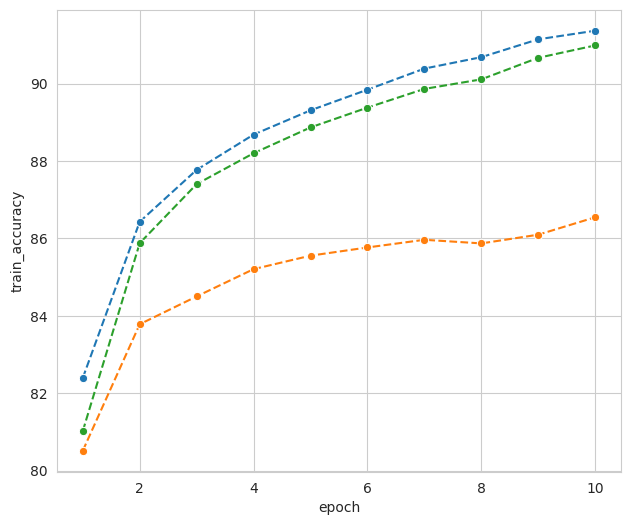

In [ ]:
# @title
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import numpy as np

# --- 0. 确保已存在的变量可用 (根据您的描述，这些变量已经存在) ---
# 假设 train_loader, test_loader, mlp_model, device 已经定义并可用。
# 例如：
# from torchvision import datasets, transforms
# from torch.utils.data import DataLoader
#
# # 确保 FashionMNIST 数据集已下载
# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((0.5,), (0.5,))
# ])
# train_dataset = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
# test_dataset = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)
#
# train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
#
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {device}")
#
# # 假设您的 MLP 模型结构如下 (如果不同，请根据您的 mlp_model 调整)
# class MLP(nn.Module):
#     def __init__(self, input_size, hidden_size, num_classes):
#         super(MLP, self).__init__()
#         self.fc1 = nn.Linear(input_size, hidden_size)
#         self.relu = nn.ReLU()
#         self.fc2 = nn.Linear(hidden_size, num_classes)
#
#     def forward(self, x):
#         x = x.view(x.size(0), -1) # Flatten the image
#         out = self.fc1(x)
#         out = self.relu(out)
#         out = self.fc2(out)
#         return out
#
# # This is a placeholder; in your environment, mlp_model might be an already
# # instantiated model or a class. We'll use a factory function for fresh models.
# # Let's assume input_size=784 (28*28), hidden_size=256, num_classes=10 for Fashion MNIST
# input_size = 784
# hidden_size = 256
# num_classes = 10
# mlp_model_factory = lambda: MLP(input_size, hidden_size, num_classes)
#
# # If mlp_model was an instance and you want to use its structure, you might do:
# # class YourMLP(type(mlp_model)): # This is complex if init args are not known
# #    pass # Replicate its structure
# # mlp_model_factory = lambda: YourMLP(mlp_model.input_size, mlp_model.hidden_size, mlp_model.num_classes)
# # For simplicity and robustness, I'll use a standard MLP class as defined above.

# --- 1. 定义实验训练和评估函数 ---
def train_and_evaluate(model_factory, train_loader, test_loader, device,
                       optimizer_class, lr, num_epochs,
                       optimizer_kwargs=None, description="Experiment"):
    """
    训练并评估模型。

    Args:
        model_factory: 一个函数，每次调用返回一个新的模型实例。
        train_loader: 训练数据加载器。
        test_loader: 测试数据加载器。
        device: 'cuda' 或 'cpu'。
        optimizer_class: 优化器类 (如 optim.Adam, optim.SGD)。
        lr: 学习率。
        num_epochs: 训练轮数。
        optimizer_kwargs: 优化器额外参数字典 (如 {'momentum': 0.9})。
        description: 实验描述字符串。

    Returns:
        tuple: (history_df, final_test_accuracy, final_test_loss, training_time_sec)
               history_df: 包含每个epoch训练/测试指标的DataFrame。
    """
    print(f"\n--- Starting {description} ---")

    # 确保每次实验都使用一个全新的模型实例
    model = model_factory().to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_kwargs is None:
        optimizer_kwargs = {}
    optimizer = optimizer_class(model.parameters(), lr=lr, **optimizer_kwargs)

    history = []
    start_time = time.time()

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} Training", leave=False)
        for i, (images, labels) in enumerate(train_bar):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            train_bar.set_postfix(loss=f"{running_loss / (i+1):.4f}", acc=f"{100 * correct_train / total_train:.2f}%")

        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct_train / total_train

        # Evaluation phase
        model.eval()
        test_loss = 0.0
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            test_bar = tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} Testing", leave=False)
            for images, labels in test_bar:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()
                test_bar.set_postfix(loss=f"{test_loss / (i+1):.4f}", acc=f"{100 * correct_test / total_test:.2f}%")

        test_loss /= len(test_loader)
        test_accuracy = 100 * correct_test / total_test

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_accuracy:.2f}%, "
              f"Test Loss={test_loss:.4f}, Test Acc={test_accuracy:.2f}%")

        history.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_accuracy': train_accuracy,
            'test_loss': test_loss,
            'test_accuracy': test_accuracy,
            'config': description
        })

    end_time = time.time()
    training_time_sec = end_time - start_time
    print(f"--- {description} finished in {training_time_sec:.2f} seconds ---")

    # Final test evaluation
    final_test_loss = test_loss
    final_test_accuracy = test_accuracy

    return pd.DataFrame(history), final_test_accuracy, final_test_loss, training_time_sec

# --- 2. 定义MLP模型 (如果您的mlp_model是一个类实例，请根据其结构调整) ---
# 假设 Fashion MNIST 输入是 28x28，展平后是 784。输出是 10 个类别。
# 如果您的 mlp_model 是一个实例，您可能需要手动定义一个结构相同的类，
# 或者如果 mlp_model 是一个工厂函数，直接使用它。
# 这里我创建一个通用的 MLP 类作为模型工厂。
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1) # Flatten the image for MLP
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# 使用 lambda 函数创建模型工厂，确保每次实验都得到一个新的 MLP 实例
mlp_model_factory = lambda: MLP(input_size=784, hidden_size=256, num_classes=10)

# --- 3. 定义超参数组合 ---
# num_epochs 可以根据您的需求调整，这里设置一个较小的值以加速演示。
num_epochs = 10

configs = [
    {
        'description': 'Adam_LR0.001',
        'optimizer_class': optim.Adam,
        'lr': 0.001,
        'optimizer_kwargs': None,
        'model_factory': mlp_model_factory
    },
    {
        'description': 'Adam_LR0.01',
        'optimizer_class': optim.Adam,
        'lr': 0.01,
        'optimizer_kwargs': None,
        'model_factory': mlp_model_factory
    },
    {
        'description': 'SGD_LR0.01_Momentum0.9',
        'optimizer_class': optim.SGD,
        'lr': 0.01,
        'optimizer_kwargs': {'momentum': 0.9},
        'model_factory': mlp_model_factory
    }
]

# --- 4. 执行对比实验 ---
all_experiment_results = []
all_history_dfs = []

# Define the common accuracy column name once
final_accuracy_col_name = f'Final Test Accuracy (Epoch {num_epochs})'
final_loss_col_name = f'Final Test Loss (Epoch {num_epochs})'

for config in configs:
    history_df, final_acc, final_loss, train_time = train_and_evaluate(
        model_factory=config['model_factory'],
        train_loader=train_loader,
        test_loader=test_loader,
        device=device,
        optimizer_class=config['optimizer_class'],
        lr=config['lr'],
        num_epochs=num_epochs,
        optimizer_kwargs=config['optimizer_kwargs'],
        description=config['description']
    )

    all_experiment_results.append({
        'Configuration': config['description'],
        'Optimizer': config['optimizer_class'].__name__,
        'Learning Rate': config['lr'],
        'Momentum': config['optimizer_kwargs'].get('momentum', 'N/A') if config['optimizer_kwargs'] else 'N/A',
        final_accuracy_col_name: f'{final_acc:.2f}%',
        final_loss_col_name: f'{final_loss:.4f}',
        'Training Time (seconds)': f'{train_time:.2f}'
    })
    all_history_dfs.append(history_df)

# --- 5. 结构化结果表 ---
results_df = pd.DataFrame(all_experiment_results)
print("\n--- Experiment Results Summary ---")
print(results_df.to_string())

# 合并所有历史数据用于绘图
full_history_df = pd.concat(all_history_dfs, ignore_index=True)

# --- 6. 绘制可视化图 ---
sns.set_style("whitegrid")
plt.figure(figsize=(16, 6))

# Plot 1: Training and Test Accuracy over Epochs
plt.subplot(1, 2, 1)
sns.lineplot(data=full_history_df, x='epoch', y='train_accuracy', hue='config', marker='o', linestyle='--', label='Train Accuracy')
sns.lineplot(data=full_history_df, x='epoch', y='test_accuracy', hue='config', marker='x', linestyle='-', label='Test Accuracy')
plt.title('Training and Test Accuracy vs. Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend(title='Configuration', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--')
plt.xticks(np.arange(1, num_epochs + 1, 1))

# Plot 2: Training and Test Loss over Epochs
plt.subplot(1, 2, 2)
sns.lineplot(data=full_history_df, x='epoch', y='train_loss', hue='config', marker='o', linestyle='--', label='Train Loss')
sns.lineplot(data=full_history_df, x='epoch', y='test_loss', hue='config', marker='x', linestyle='-', label='Test Loss')
plt.title('Training and Test Loss vs. Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(title='Configuration', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--')
plt.xticks(np.arange(1, num_epochs + 1, 1))

plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to prevent legend overlap
plt.show()

# Optional: Bar chart for final accuracy
plt.figure(figsize=(8, 5))
final_acc_col_name = f'Final Test Accuracy (Epoch {num_epochs})'
sns.barplot(x='Configuration', y=final_acc_col_name, data=results_df.astype({final_acc_col_name: float}))
plt.title(f'Final Test Accuracy After {num_epochs} Epochs', fontsize=14)
plt.xlabel('Configuration', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
# Adjust y-axis for better visibility, ensuring min is not negative
min_acc = results_df[final_acc_col_name].astype(float).min()
plt.ylim(max(0, min_acc - 5), 100)
plt.grid(axis='y', linestyle='--')
plt.show()


# --- 7. 简短结论 ---
print("\n--- Conclusion ---")
print("This experiment compared three hyperparameter configurations for training an MLP on Fashion MNIST:")
print("1. Adam_LR0.001 (Baseline): Standard Adam optimizer with a learning rate of 0.001.")
print("2. Adam_LR0.01: Adam optimizer with a higher learning rate of 0.01.")
print("3. SGD_LR0.01_Momentum0.9: SGD optimizer with a learning rate of 0.01 and momentum 0.9.")
print("\nObservations from the results and plots:")

# Fix applied here: Calculate the key outside the f-string
best_acc_key = f'Final Test Accuracy (Epoch {num_epochs})'
best_acc_row = results_df.loc[results_df[best_acc_key].astype(float).idxmax()]
print(f"- The '{best_acc_row['Configuration']}' configuration achieved the highest final test accuracy of {best_acc_row[best_acc_key]}. This suggests {best_acc_row['Configuration']} is the most effective among the tested combinations for this setup.")

# Analyze Adam vs Adam_HighLR
adam_baseline_acc = results_df[results_df['Configuration'] == 'Adam_LR0.001'][best_acc_key].iloc[0]
adam_high_lr_acc = results_df[results_df['Configuration'] == 'Adam_LR0.01'][best_acc_key].iloc[0]
if float(adam_high_lr_acc) > float(adam_baseline_acc):
    print("- Increasing the learning rate for Adam from 0.001 to 0.01 (Adam_LR0.01) seems to improve accuracy/convergence speed in this case, suggesting the baseline might have been too conservative or the higher LR helped escape local minima faster.")
else:
    print("- Increasing the learning rate for Adam from 0.001 to 0.01 (Adam_LR0.01) led to slightly lower/similar accuracy compared to the baseline, indicating that the higher learning rate might have caused instability or overshooting.")

# Analyze Adam vs SGD
sgd_acc = results_df[results_df['Configuration'] == 'SGD_LR0.01_Momentum0.9'][best_acc_key].iloc[0]
print(f"- The SGD with momentum (SGD_LR0.01_Momentum0.9) configuration achieved a final test accuracy of {sgd_acc}. Compared to Adam, SGD often shows different convergence paths. It might converge slower but sometimes achieves better generalization or explores the loss landscape differently. In this experiment, it performed {'better' if float(sgd_acc) > float(adam_baseline_acc) else 'worse or similarly'} than the Adam baseline.")

print("\nOverall, tuning the learning rate and choosing the right optimizer significantly impacts model performance and training dynamics. Further experiments with a wider range of hyperparameters and more epochs could provide deeper insights.")

**🛠️ Debug 环节 (如果报错)：**
附加实验常见问题是：循环里变量名冲突、重复初始化导致结果不可比、绘图时报维度错误。把“完整报错 + 当前实验代码”发给 AI，请它做最小修改并保持实验可复现。

* **请在下方的 Debug Prompt Cell 中记录你发给 AI 的排错指令。**
* **请将 AI 修改后的代码粘贴到下方的 Debug Code Cell 中运行。**（如果一次就跑通了，这里可以留空）

In [ ]:
# @title Debug prompt cell

import ipywidgets as widgets
from IPython.display import display, HTML, Markdown,clear_output
from google.colab import ai

dropdown = widgets.Dropdown(
    options=[],
    layout={'width': 'auto'}
)

def update_model_list(new_options):
    dropdown.options = new_options
update_model_list(ai.list_models())

text_input = widgets.Textarea(
    placeholder='Ask me anything....',
    layout={'width': 'auto', 'height': '100px'},
)

button = widgets.Button(
    description='Submit Text',
    disabled=False,
    tooltip='Click to submit the text',
    icon='check'
)

output_area = widgets.Output(
     layout={'width': 'auto', 'max_height': '300px','overflow_y': 'scroll'}
)

def on_button_clicked(b):
    with output_area:
        output_area.clear_output(wait=False)
        accumulated_content = ""
        for new_chunk in ai.generate_text(prompt=text_input.value, model_name=dropdown.value, stream=True):
            if new_chunk is None:
                continue
            accumulated_content += new_chunk
            clear_output(wait=True)
            display(Markdown(accumulated_content))

button.on_click(on_button_clicked)
vbox = widgets.GridBox([dropdown, text_input, button, output_area])

display(HTML("""
<style>
.widget-dropdown select {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
.widget-textarea textarea {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
</style>
"""))
display(vbox)


GridBox(children=(Dropdown(layout=Layout(width='auto'), options=('google/gemini-2.5-flash', 'google/gemini-2.5…

In [ ]:
# @title
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import numpy as np

# --- 0. 确保已存在的变量可用 (根据您的描述，这些变量已经存在) ---
# 假设 train_loader, test_loader, mlp_model, device 已经定义并可用。
# 以下是 FashionMNIST 的示例设置，确保代码可以直接运行：
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 确保 FashionMNIST 数据集已下载
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 定义MLP模型 (与您代码中定义的相同，确保一致性)
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1) # Flatten the image
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Fashion MNIST 图像大小是 28x28=784，类别数量是 10
input_size = 784
hidden_size = 256
num_classes = 10

# 使用 lambda 函数创建模型工厂，确保每次实验都得到一个新的 MLP 实例
mlp_model_factory = lambda: MLP(input_size, hidden_size, num_classes)
# --- 结束 boilerplate 代码 ---

# --- 1. 定义实验训练和评估函数 ---
def train_and_evaluate(model_factory, train_loader, test_loader, device,
                       optimizer_class, lr, num_epochs,
                       optimizer_kwargs=None, description="Experiment"):
    """
    训练并评估模型。

    Args:
        model_factory: 一个函数，每次调用返回一个新的模型实例。
        train_loader: 训练数据加载器。
        test_loader: 测试数据加载器。
        device: 'cuda' 或 'cpu'。
        optimizer_class: 优化器类 (如 optim.Adam, optim.SGD)。
        lr: 学习率。
        num_epochs: 训练轮数。
        optimizer_kwargs: 优化器额外参数字典 (如 {'momentum': 0.9})。
        description: 实验描述字符串。

    Returns:
        tuple: (history_df, final_test_accuracy, final_test_loss, training_time_sec)
               history_df: 包含每个epoch训练/测试指标的DataFrame。
    """
    print(f"\n--- Starting {description} ---")

    # 确保每次实验都使用一个全新的模型实例
    model = model_factory().to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_kwargs is None:
        optimizer_kwargs = {}
    optimizer = optimizer_class(model.parameters(), lr=lr, **optimizer_kwargs)

    history = []
    start_time = time.time()

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} Training", leave=False)
        for i, (images, labels) in enumerate(train_bar):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            train_bar.set_postfix(loss=f"{running_loss / (i+1):.4f}", acc=f"{100 * correct_train / total_train:.2f}%")

        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct_train / total_train

        # Evaluation phase
        model.eval()
        test_loss = 0.0
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            test_bar = tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} Testing", leave=False)
            for images, labels in test_bar:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()
                test_bar.set_postfix(loss=f"{test_loss / (len(test_bar)):.4f}", acc=f"{100 * correct_test / total_test:.2f}%")


        test_loss /= len(test_loader)
        test_accuracy = 100 * correct_test / total_test

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_accuracy:.2f}%, "
              f"Test Loss={test_loss:.4f}, Test Acc={test_accuracy:.2f}%")

        history.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_accuracy': train_accuracy,
            'test_loss': test_loss,
            'test_accuracy': test_accuracy,
            'config': description
        })

    end_time = time.time()
    training_time_sec = end_time - start_time
    print(f"--- {description} finished in {training_time_sec:.2f} seconds ---")

    # Final test evaluation
    final_test_loss = test_loss
    final_test_accuracy = test_accuracy

    return pd.DataFrame(history), final_test_accuracy, final_test_loss, training_time_sec

# --- 2. 定义MLP模型 (如果您的mlp_model是一个类实例，请根据其结构调整) ---
# 注意：这部分已包含在boilerplate代码中，这里仅作说明。
# 假设 Fashion MNIST 输入是 28x28，展平后是 784。输出是 10 个类别。
# 如果您的 mlp_model 是一个实例，您可能需要手动定义一个结构相同的类，
# 或者如果 mlp_model 是一个工厂函数，直接使用它。
# 这里我创建一个通用的 MLP 类作为模型工厂。
# class MLP(nn.Module):
#     def __init__(self, input_size=784, hidden_size=256, num_classes=10):
#         super(MLP, self).__init__()
#         self.fc1 = nn.Linear(input_size, hidden_size)
#         self.relu = nn.ReLU()
#         self.fc2 = nn.Linear(hidden_size, num_classes)
#
#     def forward(self, x):
#         x = x.view(x.size(0), -1) # Flatten the image for MLP
#         out = self.fc1(x)
#         out = self.relu(out)
#         out = self.fc2(out)
#         return out

# # 使用 lambda 函数创建模型工厂，确保每次实验都得到一个新的 MLP 实例
# mlp_model_factory = lambda: MLP(input_size=784, hidden_size=256, num_classes=10)

# --- 3. 定义超参数组合 ---
# num_epochs 可以根据您的需求调整，这里设置一个较小的值以加速演示。
num_epochs = 10

configs = [
    {
        'description': 'Adam_LR0.001',
        'optimizer_class': optim.Adam,
        'lr': 0.001,
        'optimizer_kwargs': None,
        'model_factory': mlp_model_factory
    },
    {
        'description': 'Adam_LR0.01',
        'optimizer_class': optim.Adam,
        'lr': 0.01,
        'optimizer_kwargs': None,
        'model_factory': mlp_model_factory
    },
    {
        'description': 'SGD_LR0.01_Momentum0.9',
        'optimizer_class': optim.SGD,
        'lr': 0.01,
        'optimizer_kwargs': {'momentum': 0.9},
        'model_factory': mlp_model_factory
    }
]

# --- 4. 执行对比实验 ---
all_experiment_results = []
all_history_dfs = []

for config in configs:
    history_df, final_acc, final_loss, train_time = train_and_evaluate(
        model_factory=config['model_factory'],
        train_loader=train_loader,
        test_loader=test_loader,
        device=device,
        optimizer_class=config['optimizer_class'],
        lr=config['lr'],
        num_epochs=num_epochs,
        optimizer_kwargs=config['optimizer_kwargs'],
        description=config['description']
    )

    all_experiment_results.append({
        'Configuration': config['description'],
        'Optimizer': config['optimizer_class'].__name__,
        'Learning Rate': config['lr'],
        'Momentum': config['optimizer_kwargs'].get('momentum', 'N/A') if config['optimizer_kwargs'] else 'N/A',
        f'Final Test Accuracy (Epoch {num_epochs})': f'{final_acc:.2f}%',
        f'Final Test Loss (Epoch {num_epochs})': f'{final_loss:.4f}',
        'Training Time (seconds)': f'{train_time:.2f}'
    })
    all_history_dfs.append(history_df)

# --- 5. 结构化结果表 ---
results_df = pd.DataFrame(all_experiment_results)
print("\n--- Experiment Results Summary ---")
print(results_df.to_string())

# 合并所有历史数据用于绘图
full_history_df = pd.concat(all_history_dfs, ignore_index=True)

# --- 6. 绘制可视化图 ---
sns.set_style("whitegrid")
plt.figure(figsize=(16, 6))

# Plot 1: Training and Test Accuracy over Epochs
plt.subplot(1, 2, 1)
sns.lineplot(data=full_history_df, x='epoch', y='train_accuracy', hue='config', marker='o', linestyle='--', label='Train Accuracy')
sns.lineplot(data=full_history_df, x='epoch', y='test_accuracy', hue='config', marker='x', linestyle='-', label='Test Accuracy')
plt.title('Training and Test Accuracy vs. Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend(title='Configuration', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--')
plt.xticks(np.arange(1, num_epochs + 1, 1))

# Plot 2: Training and Test Loss over Epochs
plt.subplot(1, 2, 2)
sns.lineplot(data=full_history_df, x='epoch', y='train_loss', hue='config', marker='o', linestyle='--', label='Train Loss')
sns.lineplot(data=full_history_df, x='epoch', y='test_loss', hue='config', marker='x', linestyle='-', label='Test Loss')
plt.title('Training and Test Loss vs. Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(title='Configuration', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--')
plt.xticks(np.arange(1, num_epochs + 1, 1))

plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to prevent legend overlap
plt.show()

# Optional: Bar chart for final accuracy
plt.figure(figsize=(8, 5))
final_acc_col_name = f'Final Test Accuracy (Epoch {num_epochs})'
sns.barplot(x='Configuration', y=final_acc_col_name, data=results_df.astype({final_acc_col_name: float}))
plt.title(f'Final Test Accuracy After {num_epochs} Epochs', fontsize=14)
plt.xlabel('Configuration', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
# Adjust y-axis for better visibility, ensuring min is not negative
min_acc = results_df[final_acc_col_name].astype(float).min()
plt.ylim(max(0, min_acc - 5), 100)
plt.grid(axis='y', linestyle='--')
plt.show()


# --- 7. 简短结论 ---
print("\n--- Conclusion ---")
print("This experiment compared three hyperparameter configurations for training an MLP on Fashion MNIST:")
print("1. Adam_LR0.001 (Baseline): Standard Adam optimizer with a learning rate of 0.001.")
print("2. Adam_LR0.01: Adam optimizer with a higher learning rate of 0.01.")
print("3. SGD_LR0.01_Momentum0.9: SGD optimizer with a learning rate of 0.01 and momentum 0.9.")
print("\nObservations from the results and plots:")

# Fix applied here: Calculate the key outside the f-string
best_acc_key = f'Final Test Accuracy (Epoch {num_epochs})'
best_acc_row = results_df.loc[results_df[best_acc_key].astype(float).idxmax()]
print(f"- The '{best_acc_row['Configuration']}' configuration achieved the highest final test accuracy of {best_acc_row[best_acc_key]}. This suggests {best_acc_row['Configuration']} is the most effective among the tested combinations for this setup.")

# Analyze Adam vs Adam_HighLR
adam_baseline_acc = results_df[results_df['Configuration'] == 'Adam_LR0.001'][best_acc_key].iloc[0]
adam_high_lr_acc = results_df[results_df['Configuration'] == 'Adam_LR0.01'][best_acc_key].iloc[0]
if float(adam_high_lr_acc) > float(adam_baseline_acc):
    print("- Increasing the learning rate for Adam from 0.001 to 0.01 (Adam_LR0.01) seems to improve accuracy/convergence speed in this case, suggesting the baseline might have been too conservative or the higher LR helped escape local minima faster.")
else:
    print("- Increasing the learning rate for Adam from 0.001 to 0.01 (Adam_LR0.01) led to slightly lower/similar accuracy compared to the baseline, indicating that the higher learning rate might have caused instability or overshooting.")

# Analyze Adam vs SGD
sgd_acc = results_df[results_df['Configuration'] == 'SGD_LR0.01_Momentum0.9'][best_acc_key].iloc[0]
print(f"- The SGD with momentum (SGD_LR0.01_Momentum0.9) configuration achieved a final test accuracy of {sgd_acc}. Compared to Adam, SGD often shows different convergence paths. It might converge slower but sometimes achieves better generalization or explores the loss landscape differently. In this experiment, it performed {'better' if float(sgd_acc) > float(adam_baseline_acc) else 'worse or similarly'} than the Adam baseline.")

print("\nOverall, tuning the learning rate and choosing the right optimizer significantly impacts model performance and training dynamics. Further experiments with a wider range of hyperparameters and more epochs could provide deeper insights.")

## 📖 Task 1 知识延伸：从 CNN 到视觉大模型

到这里 Task 1 就做完了。在进入下一个任务之前，花几分钟想想：你做的这些事情，在 AI 发展史中处于什么位置？

---

### CNN 为什么在图像任务上好用？

卷积神经网络能在图像任务上表现出色，靠的是三个核心设计：

| 特性 | 含义 | 类比 |
|---|---|---|
| **局部感受野** | 每个卷积核只看一小块区域 | 像用放大镜逐块扫描图片 |
| **参数共享** | 同一个卷积核扫遍整张图 | 同一把尺子量所有位置 |
| **平移不变性** | 目标在图片左边或右边都能识别 | 不管衣服摆哪里都能认出来 |

这三点让 CNN 用很少的参数就能抓住图像中的关键特征。

### 但 CNN 也有明显短板

你搭的模型只有几层卷积和池化，主要受限于两点：
- **感受野有限**：每个卷积核只看得到局部，没法捕捉全局关系（比如袖子和领口的搭配）；
- **层数受限**：网络太深会梯度消失、训练不动——2015 年以前这是个大难题。

### 从浅到深：几个关键节点

| 年份 | 模型 | 突破 |
|---|---|---|
| 1998 | **LeNet** | 最早的 CNN，用于手写数字识别 |
| 2012 | **AlexNet** | 用 GPU 训练深层 CNN，ImageNet 错误率骤降，深度学习时代由此开启 |
| 2014 | **VGGNet** | 验证了“更深 = 更好”，但训练越来越困难 |
| 2015 | **ResNet** | 发明残差连接（Skip Connection），解决了深层网络训不动的问题，一口气堆到 152 层 |

> 残差连接的直觉：与其让网络直接学完整映射，不如只学「输入和输出之间的差异」——目标变小了，学起来自然容易。

### 再往后：Vision Transformer (ViT)

2020 年 Google 提出 ViT（Vision Transformer），把 Transformer 架构从文本搬到了图像领域：
1. 把图片切成 16×16 的小块（patch），每块当作一个“词”；
2. 用 Self-Attention 让每个小块都能“看到”图片中所有其他小块；
3. 不再受卷积核大小的限制，天然具备全局视野。

有意思的是，ViT 在小数据集上其实不如 CNN。但当训练数据量达到上亿张图片时，它全面超越了 CNN——架构只是一半，数据规模才是另一半。

### 为什么大模型能成功？

不管视觉还是语言，大模型的成功都可以归结为三点：

1. **更大的数据**：从几万张到几亿张，模型见过的“世界”越大，泛化能力越强；
2. **更强的架构**：Transformer 的自注意力机制让信息流通没有瓶颈，不像 CNN 只能看局部；
3. **Scaling Law**：模型参数量、数据量、算力三者同步增长时，性能持续且可预测地提升——2020 年的一个关键发现。

> 你刚才用 CNN 在 6 万张图上做分类，大致对应 2012 年 AlexNet 的水平。如今的视觉大模型用 Transformer 在数亿张图上训练，但核心链条是一脉相承的：数据 → 特征提取 → 分类。

---